## 1.1. Source des Données

* **Méthodologie :** L'ensemble des données a été collecté en utilisant la technique de **Web Scraping**.
* **Plateforme :** Les annonces immobilières ont été extraites depuis le portail immobilier marocain : [https://www.mubawab.ma/](https://www.mubawab.ma/).
* **Fichier de référence :** `maisonlux_maroc_complet.csv`

## 1.2. Dictionnaire des Données

Le tableau ci-dessous décrit chaque colonne présente dans le jeu de données brut :

| Nom de la Colonne | Type Actuel (Pandas) | Description |
| :--- | :--- | :--- |
| **Titre** | `object` (String) | L'intitulé ou l'accroche descriptive de l'annonce immobilière (ex: "Studios Neufs A Vendre..."). |
| **Prix** | `object` (String) | Le prix affiché du bien. Contient le montant et la devise (DH, EUR) ou des mentions textuelles (ex: "Projet"). |
| **Localisation** | `object` (String) | L'emplacement géographique du bien. Format variable : "Quartier, Ville" ou simplement "Ville". |
| **Details** | `object` (String) | Chaîne de caractères concaténée regroupant les caractéristiques techniques (surface en m², nombre de pièces, de chambres, et de salles de bains). |

## 1.3. Observations Générales et Problématiques (Insights)

* **Nature des Données (Raw Data) :** Étant issues du web scraping, toutes les colonnes sont actuellement au format texte brut (`object`). Les variables qui devraient logiquement être quantitatives (Prix, Surface, etc.) nécessitent un nettoyage et une conversion.
* **Variable Cible (Target Variable - Prix) :** 
  * Le format textuel actuel empêche toute modélisation mathématique. 
  * Présence de différentes devises ("DH", "EUR") nécessitant une uniformisation vers une devise unique (MAD).
  * Présence de valeurs aberrantes ou textuelles (ex: "Projet · 10 biens immobiliers") qui devront être traitées.
* **Granularité de la Localisation :** La colonne `Localisation` n'est pas standardisée. Il sera nécessaire de la diviser (Split) pour extraire la `Ville` et le `Quartier` en tant que variables catégorielles distinctes.
* **Extraction des Caractéristiques (Feature Extraction) :** La colonne `Details` regroupe plusieurs informations techniques sur une seule ligne. L'utilisation d'expressions régulières (Regex) sera indispensable pour extraire ces informations et créer les nouvelles colonnes numériques suivantes :
  * `Surface_m2`
  * `Pieces`
  * `Chambres`
  * `Salles_Bains`

# 1- importation des bibliothèque 

In [112]:
import pandas as pd     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor ,plot_tree
from statistics import linear_regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import re
from sklearn.base import BaseEstimator, TransformerMixin

In [113]:
df = pd.read_csv('maisonlux_maroc_complet.csv')
df.head(10)

,Titre,Prix,Localisation,Details
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730 000 DH,"Guéliz, Marrakech",42 m² 2 Pièces 1 Ch. 1 Salle de bain
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980 000 DH,"Route de Ouarzazate, Marrakech",116 m² 3 Pièces 2 Chambres 2 Salles de bains
2,Appartement centre ville investissement locatif,1 290 000 EUR,"Guéliz, Marrakech",61 m² 2 Pièces 1 Ch. 1 Salle de bain
3,Green Lotus,Projet · 10 biens immobiliers,"Sidi Maarouf, Casablanca",Haut standing En cours de construction Livrais...
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1 242 000 DH,"Les Hôpitaux, Casablanca",47 m² 1 Pièce 1 Ch. 1 Salle de bain
5,Appartement à l'achat à Californie. 2 chambres...,1 712 500 DH,"Californie, Casablanca",100 m² 3 Pièces 2 Chambres 2 Salles de bains
6,Vente d'un bel appartement à Belvédère. 2 bell...,950 000 DH,"Belvédère, Casablanca",82 m² 3 Pièces 2 Chambres 1 Salle de bain
7,Appartement neuf résidence azzahra 2 said hajji,370 000 DH,"Abouab Sala, Salé",53 m² 3 Pièces 2 Chambres 1 Salle de bain
8,Residence Montarista,À partir de 3 800 000 DH,"Route de Tahanaout, Marrakech",Haut standing En cours de construction Livrais...
9,Superbe appartement à casablanca: 181 m² 2 pp,2 800 000 DH,"Maârif Extension, Casablanca",181 m² 3 Pièces 3 Chambres 2 Salles de bains


In [114]:
df.tail(10)

,Titre,Prix,Localisation,Details
16848,Vente superbe appartement 189m2 avec terrasse ...,4 200 000 DH,"Ain Diab, Casablanca",189 m² 4 Pièces 3 Chambres 3 Salles de bains
16849,Bijou terrasse soleil proche onomo,1 750 000 DH,Casablanca,114 m² 3 Pièces 2 Chambres 1 Salle de bain
16850,Terrasse gauthier belle affaire,900 000 DH,Casablanca,62 m² 2 Pièces 1 Ch. 1 Salle de bain
16851,Spacieux moderne terrasse soleil,4 500 000 DH,"Gauthier, Casablanca",257 m² 5 Pièces 3 Chambres 2 Salles de bains
16852,Meuble en plein coeur de gauthier,850 000 DH,Casablanca,48 m² 2 Pièces 1 Ch. 1 Salle de bain
16853,Appartement avec terrasse,8 000 DH,"Anfa, Casablanca",70 m² 1 Ch. 1 Salle de bain
16854,Coup de fusil vue unique sur casablanca,2 500 000 DH,"Bourgogne Est, Casablanca",223 m² 3 Chambres 2 Salles de bains
16855,Proche zara bel appartement etage eleve,2 300 000 DH,Casablanca,140 m² 5 Pièces 3 Chambres 2 Salles de bains
16856,Socrate mawlid,1 300 000 DH,Casablanca,108 m² 3 Pièces 2 Chambres 2 Salles de bains
16857,Bel emplacement bourgogne,2 600 000 DH,"Bourgogne Ouest, Casablanca",140 m² 5 Pièces 3 Chambres 2 Salles de bains


# 2- Compréhension des Données

In [115]:
df.shape

(16858, 4)

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16858 entries, 0 to 16857
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Titre         16858 non-null  object
 1   Prix          16858 non-null  object
 2   Localisation  16858 non-null  object
 3   Details       16858 non-null  object
dtypes: object(4)
memory usage: 526.9+ KB


In [117]:
df.isnull().sum()

Titre           0
Prix            0
Localisation    0
Details         0
dtype: int64

In [118]:
df.duplicated().sum()

1006

In [119]:
df.drop_duplicates(inplace=True)

In [120]:
df.duplicated().sum()

0

In [121]:
df.describe()

,Titre,Prix,Localisation,Details
count,15852,15852,15852,15852
unique,14791,1838,906,5179
top,Appartement à vendre,Prix à consulter,"Guéliz, Marrakech",60 m² 3 Pièces 2 Chambres 1 Salle de bain
freq,170,1164,784,79


# 3- data cleaning 

 3-1 nettoyage de colonne Titre

In [122]:
df['Titre'].head(50)

0       Studios Neufs A Vendre Le Vrai Centre de Gueliz
1     Appartement Rez de jardin avec 300m2 Jardin Privé
2       Appartement centre ville investissement locatif
3                                           Green Lotus
4     Appartement à vendre à Les Hôpitaux. 1 chambre...
5     Appartement à l'achat à Californie. 2 chambres...
6     Vente d'un bel appartement à Belvédère. 2 bell...
7       Appartement neuf résidence azzahra 2 said hajji
8                                  Residence Montarista
9        Superbe appartement à casablanca: 181 m²  2 pp
10         Studios & Appartements à vendre avec piscine
11                      Joli studio meublé à noria golf
12     À louer – appartement 200 m² – haut agdal, rabat
13    Appartement à vendre à Les Hôpitaux. 1 belle c...
14      Vend appartement à Martil. Surface totale 55 m²
15    Appartement à l'achat à Tanger quartier Ziaten...
16    Appartement à l'achat à Bournazil. Superficie ...
17             Appartement à vendre à Sidi Moume

In [123]:
import pandas as pd

def apply_one_hot_encoding(df):
    """
    Fonction bach n-creer colonnes binaire (1/0)
    b tariqa auto o i7tirafiya.
    """
    df = df.copy()
    
    # 1. N-creeriw dictionary fih l-types li bghina n-detectiw
    # L-key hiya smit l-colonne, w l-value hiya l-mot l-miftah
    mapping = {
        'type_appartement': 'APPARTEMENT',
        'type_studio': 'STUDIO',
        'type_maison': 'MAISON',
        'type_villa': 'VILLA',
        'type_duplex': 'DUPLEX'
    }
    
    # 2. N-applyiw l-logique (b str.contains)
    titres = df['Titre'].str.upper().fillna('')
    
    for col_name, pattern in mapping.items():
        # .astype(int) hiya li kat-rdha 1 aw 0
        df[col_name] = titres.str.contains(pattern, regex=True).astype(int)
        
    return df

# --- EXECUTION ---
# N-tba99ouha 3la l-df dyalna
df = apply_one_hot_encoding(df)

# Résultat
print("✅colonnes One-Hot Encoding t-creyaw b n-naja7:")
print(df[['Titre', 'type_appartement', 'type_studio', 'type_maison', 'type_villa', 'type_duplex']].head(10))

✅colonnes One-Hot Encoding t-creyaw b n-naja7:
                                               Titre  type_appartement  \
0    Studios Neufs A Vendre Le Vrai Centre de Gueliz                 0   
1  Appartement Rez de jardin avec 300m2 Jardin Privé                 1   
2    Appartement centre ville investissement locatif                 1   
3                                        Green Lotus                 0   
4  Appartement à vendre à Les Hôpitaux. 1 chambre...                 1   
5  Appartement à l'achat à Californie. 2 chambres...                 1   
6  Vente d'un bel appartement à Belvédère. 2 bell...                 1   
7    Appartement neuf résidence azzahra 2 said hajji                 1   
8                               Residence Montarista                 0   
9     Superbe appartement à casablanca: 181 m²  2 pp                 1   

   type_studio  type_maison  type_villa  type_duplex  
0            1            0           0            0  
1            0            0 

In [124]:
df

,Titre,Prix,Localisation,Details,type_appartement,type_studio,type_maison,type_villa,type_duplex
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730 000 DH,"Guéliz, Marrakech",42 m² 2 Pièces 1 Ch. 1 Salle de bain,0,1,0,0,0
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980 000 DH,"Route de Ouarzazate, Marrakech",116 m² 3 Pièces 2 Chambres 2 Salles de bains,1,0,0,0,0
2,Appartement centre ville investissement locatif,1 290 000 EUR,"Guéliz, Marrakech",61 m² 2 Pièces 1 Ch. 1 Salle de bain,1,0,0,0,0
3,Green Lotus,Projet · 10 biens immobiliers,"Sidi Maarouf, Casablanca",Haut standing En cours de construction Livrais...,0,0,0,0,0
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1 242 000 DH,"Les Hôpitaux, Casablanca",47 m² 1 Pièce 1 Ch. 1 Salle de bain,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
16853,Appartement avec terrasse,8 000 DH,"Anfa, Casablanca",70 m² 1 Ch. 1 Salle de bain,1,0,0,0,0
16854,Coup de fusil vue unique sur casablanca,2 500 000 DH,"Bourgogne Est, Casablanca",223 m² 3 Chambres 2 Salles de bains,0,0,0,0,0
16855,Proche zara bel appartement etage eleve,2 300 000 DH,Casablanca,140 m² 5 Pièces 3 Chambres 2 Salles de bains,1,0,0,0,0
16856,Socrate mawlid,1 300 000 DH,Casablanca,108 m² 3 Pièces 2 Chambres 2 Salles de bains,0,0,0,0,0


3-2 la colonne Prix

- Espaces insécables (\xa0) w l'espace normal: kibanou bhal f 730 000 DH w homa kaykhelwiw l'ordinateur yqraha ka string machi float.

- Devises mokhtalifa: kayn des prix b DH w khrin b EUR (khssna nwahdo kolchi l MAD).

- Texte zayd: kayn des valeurs bhal À partir de 3 800 000 DH.

- Valeurs non numériques: bhal Prix à consulter awla Projet · 10 biens immobiliers. Hadok machi des prix utilisables.

In [125]:

class PrixCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, taux_conversion_eur_mad=10.8):
        self.taux = taux_conversion_eur_mad
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_clean = X.copy()
        # Hna ghadi n-remplacew la colonne 'Prix' f blassetha
        X_clean['Prix'] = X_clean['Prix'].apply(self._clean_single_price)
        return X_clean
        
    def _clean_single_price(self, x):
        if pd.isna(x) or "consulter" in str(x).lower() or "projet" in str(x).lower():
            return np.nan
        
        x_str = str(x).lower().replace('à partir de', '').strip()
        is_eur = 'eur' in x_str
        num_str = re.sub(r'[^\d]', '', x_str)
        
        if not num_str: 
            return np.nan
        
        prix = float(num_str)
        return prix * self.taux if is_eur else prix
    

    # 1. Initialiser le Transformer
cleaner = PrixCleaner()

# 2. Appliquer le nettoyage w t-sauvegardi le résultat (hada howa l'étape li katnsa bzaf)
df = cleaner.fit_transform(df)

# 3. Afficher la colonne bach t-vérifier
print(df[['Prix']].head(10))

         Prix
0    730000.0
1    980000.0
2  13932000.0
3         NaN
4   1242000.0
5   1712500.0
6    950000.0
7    370000.0
8   3800000.0
9   2800000.0


In [126]:
df.head(10)

,Titre,Prix,Localisation,Details,type_appartement,type_studio,type_maison,type_villa,type_duplex
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730000.0,"Guéliz, Marrakech",42 m² 2 Pièces 1 Ch. 1 Salle de bain,0,1,0,0,0
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980000.0,"Route de Ouarzazate, Marrakech",116 m² 3 Pièces 2 Chambres 2 Salles de bains,1,0,0,0,0
2,Appartement centre ville investissement locatif,13932000.0,"Guéliz, Marrakech",61 m² 2 Pièces 1 Ch. 1 Salle de bain,1,0,0,0,0
3,Green Lotus,NaN,"Sidi Maarouf, Casablanca",Haut standing En cours de construction Livrais...,0,0,0,0,0
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1242000.0,"Les Hôpitaux, Casablanca",47 m² 1 Pièce 1 Ch. 1 Salle de bain,1,0,0,0,0
5,Appartement à l'achat à Californie. 2 chambres...,1712500.0,"Californie, Casablanca",100 m² 3 Pièces 2 Chambres 2 Salles de bains,1,0,0,0,0
6,Vente d'un bel appartement à Belvédère. 2 bell...,950000.0,"Belvédère, Casablanca",82 m² 3 Pièces 2 Chambres 1 Salle de bain,1,0,0,0,0
7,Appartement neuf résidence azzahra 2 said hajji,370000.0,"Abouab Sala, Salé",53 m² 3 Pièces 2 Chambres 1 Salle de bain,1,0,0,0,0
8,Residence Montarista,3800000.0,"Route de Tahanaout, Marrakech",Haut standing En cours de construction Livrais...,0,0,0,0,0
9,Superbe appartement à casablanca: 181 m² 2 pp,2800000.0,"Maârif Extension, Casablanca",181 m² 3 Pièces 3 Chambres 2 Salles de bains,1,0,0,0,0


In [127]:
df['Prix'].isnull().sum()

1169

In [128]:
df.dropna(subset=['Prix'], inplace=True)

3-3 la colonne Localisation

In [129]:
import pandas as pd

# 1. N-3awdo n-dirou split b tariqa mzyana o n-véri-fiw l-comma
def nettoyer_localisation(row):
    loc = str(row['Localisation'])
    if ',' in loc:
        parts = loc.split(',', 1)
        return pd.Series([parts[0].strip(), parts[1].strip()])
    else:
        # Ila makantch comma, ya3ni ghir ism l-ville li maktob (bhal "Rabat" aw "Tanger")
        return pd.Series([None, loc.strip()])

# N-tbaqquha 3la l-dataframe
df[['Quartier', 'Ville']] = df.apply(nettoyer_localisation, axis=1)

print("✅ T-naddaf l-hal! Daba les quartiers w les villes m-fsslin b dabet.")
print(df[['Localisation', 'Quartier', 'Ville']].head(10))

✅ T-naddaf l-hal! Daba les quartiers w les villes m-fsslin b dabet.
                      Localisation             Quartier       Ville
0                Guéliz, Marrakech               Guéliz   Marrakech
1   Route de Ouarzazate, Marrakech  Route de Ouarzazate   Marrakech
2                Guéliz, Marrakech               Guéliz   Marrakech
4         Les Hôpitaux, Casablanca         Les Hôpitaux  Casablanca
5           Californie, Casablanca           Californie  Casablanca
6            Belvédère, Casablanca            Belvédère  Casablanca
7                Abouab Sala, Salé          Abouab Sala        Salé
8    Route de Tahanaout, Marrakech   Route de Tahanaout   Marrakech
9     Maârif Extension, Casablanca     Maârif Extension  Casablanca
10                Agdal, Marrakech                Agdal   Marrakech


In [130]:
df.head(10)

,Titre,Prix,Localisation,Details,type_appartement,type_studio,type_maison,type_villa,type_duplex,Quartier,Ville
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730000.0,"Guéliz, Marrakech",42 m² 2 Pièces 1 Ch. 1 Salle de bain,0,1,0,0,0,Guéliz,Marrakech
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980000.0,"Route de Ouarzazate, Marrakech",116 m² 3 Pièces 2 Chambres 2 Salles de bains,1,0,0,0,0,Route de Ouarzazate,Marrakech
2,Appartement centre ville investissement locatif,13932000.0,"Guéliz, Marrakech",61 m² 2 Pièces 1 Ch. 1 Salle de bain,1,0,0,0,0,Guéliz,Marrakech
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1242000.0,"Les Hôpitaux, Casablanca",47 m² 1 Pièce 1 Ch. 1 Salle de bain,1,0,0,0,0,Les Hôpitaux,Casablanca
5,Appartement à l'achat à Californie. 2 chambres...,1712500.0,"Californie, Casablanca",100 m² 3 Pièces 2 Chambres 2 Salles de bains,1,0,0,0,0,Californie,Casablanca
6,Vente d'un bel appartement à Belvédère. 2 bell...,950000.0,"Belvédère, Casablanca",82 m² 3 Pièces 2 Chambres 1 Salle de bain,1,0,0,0,0,Belvédère,Casablanca
7,Appartement neuf résidence azzahra 2 said hajji,370000.0,"Abouab Sala, Salé",53 m² 3 Pièces 2 Chambres 1 Salle de bain,1,0,0,0,0,Abouab Sala,Salé
8,Residence Montarista,3800000.0,"Route de Tahanaout, Marrakech",Haut standing En cours de construction Livrais...,0,0,0,0,0,Route de Tahanaout,Marrakech
9,Superbe appartement à casablanca: 181 m² 2 pp,2800000.0,"Maârif Extension, Casablanca",181 m² 3 Pièces 3 Chambres 2 Salles de bains,1,0,0,0,0,Maârif Extension,Casablanca
10,Studios & Appartements à vendre avec piscine,1300000.0,"Agdal, Marrakech",58 m² 1 Pièce 1 Ch. 1 Salle de bain,1,1,0,0,0,Agdal,Marrakech


3-4 la colonne Details 

In [131]:
from sklearn.base import BaseEstimator, TransformerMixin
import re
import pandas as pd
import numpy as np

class DetailsExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_clean = X.copy()
        
        # S'assurer que tout est sous forme de texte
        details = X_clean['Details'].astype(str)
        
        # 1. Extraction des Variables Numériques avec Regex
        # \d+ veut dire "chercher n'importe quel nombre"
        X_clean['Surface_m2'] = details.str.extract(r'(\d+)\s*m²').astype(float)
        X_clean['Pieces'] = details.str.extract(r'(\d+)\s*Pièce').astype(float)
        # On cherche 'Chambres' ou juste 'Ch.'
        X_clean['Chambres'] = details.str.extract(r'(\d+)\s*Ch').astype(float)
        # On cherche 'Salle' (pour prendre Salle de bain ou Salles de bains)
        X_clean['Salles_Bain'] = details.str.extract(r'(\d+)\s*Salle').astype(float)
        
        # 2. Extraction des Variables Catégoriques / Binaires (Flags)
        # On crée des colonnes (1 si vrai, 0 si faux)
        X_clean['Is_Haut_Standing'] = details.str.contains('Haut standing', case=False, na=False).astype(int)
        X_clean['En_Construction'] = details.str.contains('En cours de construction', case=False, na=False).astype(int)
        
        # 3. Suppression de la colonne d'origine
        X_clean.drop(columns=['Details'], inplace=True)
        
        return X_clean
    


# Initialiser l'extracteur
extractor = DetailsExtractor()

# Appliquer sur ton dataframe
df = extractor.fit_transform(df)
df.head(10)

,Titre,Prix,Localisation,type_appartement,type_studio,type_maison,type_villa,type_duplex,Quartier,Ville,Surface_m2,Pieces,Chambres,Salles_Bain,Is_Haut_Standing,En_Construction
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730000.0,"Guéliz, Marrakech",0,1,0,0,0,Guéliz,Marrakech,42.0,2.0,1.0,1.0,0,0
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980000.0,"Route de Ouarzazate, Marrakech",1,0,0,0,0,Route de Ouarzazate,Marrakech,116.0,3.0,2.0,2.0,0,0
2,Appartement centre ville investissement locatif,13932000.0,"Guéliz, Marrakech",1,0,0,0,0,Guéliz,Marrakech,61.0,2.0,1.0,1.0,0,0
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1242000.0,"Les Hôpitaux, Casablanca",1,0,0,0,0,Les Hôpitaux,Casablanca,47.0,1.0,1.0,1.0,0,0
5,Appartement à l'achat à Californie. 2 chambres...,1712500.0,"Californie, Casablanca",1,0,0,0,0,Californie,Casablanca,100.0,3.0,2.0,2.0,0,0
6,Vente d'un bel appartement à Belvédère. 2 bell...,950000.0,"Belvédère, Casablanca",1,0,0,0,0,Belvédère,Casablanca,82.0,3.0,2.0,1.0,0,0
7,Appartement neuf résidence azzahra 2 said hajji,370000.0,"Abouab Sala, Salé",1,0,0,0,0,Abouab Sala,Salé,53.0,3.0,2.0,1.0,0,0
8,Residence Montarista,3800000.0,"Route de Tahanaout, Marrakech",0,0,0,0,0,Route de Tahanaout,Marrakech,NaN,NaN,NaN,NaN,1,1
9,Superbe appartement à casablanca: 181 m² 2 pp,2800000.0,"Maârif Extension, Casablanca",1,0,0,0,0,Maârif Extension,Casablanca,181.0,3.0,3.0,2.0,0,0
10,Studios & Appartements à vendre avec piscine,1300000.0,"Agdal, Marrakech",1,1,0,0,0,Agdal,Marrakech,58.0,1.0,1.0,1.0,0,0


In [132]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Prix,14683.0,2.534671e+06,1.724687e+07,6400.0,750000.0,1300000.0,2140000.0,950000000.0
type_appartement,14683.0,8.020840e-01,3.984420e-01,0.0,1.0,1.0,1.0,1.0
type_studio,14683.0,4.249813e-02,2.017295e-01,0.0,0.0,0.0,0.0,1.0
type_maison,14683.0,4.631206e-03,6.789751e-02,0.0,0.0,0.0,0.0,1.0
type_villa,14683.0,7.083021e-03,8.386496e-02,0.0,0.0,0.0,0.0,1.0
type_duplex,14683.0,3.064769e-02,1.723671e-01,0.0,0.0,0.0,0.0,1.0
Surface_m2,14599.0,1.222210e+02,4.578883e+02,11.0,73.0,98.0,133.0,50000.0
Pieces,13160.0,3.461930e+00,1.893769e+00,1.0,2.0,3.0,4.0,41.0
Chambres,14514.0,2.403748e+00,9.843408e-01,1.0,2.0,2.0,3.0,30.0
Salles_Bain,14432.0,1.793168e+00,8.391372e-01,1.0,1.0,2.0,2.0,18.0


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14683 entries, 0 to 16857
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Titre             14683 non-null  object 
 1   Prix              14683 non-null  float64
 2   Localisation      14683 non-null  object 
 3   type_appartement  14683 non-null  int32  
 4   type_studio       14683 non-null  int32  
 5   type_maison       14683 non-null  int32  
 6   type_villa        14683 non-null  int32  
 7   type_duplex       14683 non-null  int32  
 8   Quartier          14316 non-null  object 
 9   Ville             14683 non-null  object 
 10  Surface_m2        14599 non-null  float64
 11  Pieces            13160 non-null  float64
 12  Chambres          14514 non-null  float64
 13  Salles_Bain       14432 non-null  float64
 14  Is_Haut_Standing  14683 non-null  int32  
 15  En_Construction   14683 non-null  int32  
dtypes: float64(5), int32(7), object(4)
memory usa

### nettoyage des anomalies avec ISOLATION FOREST 

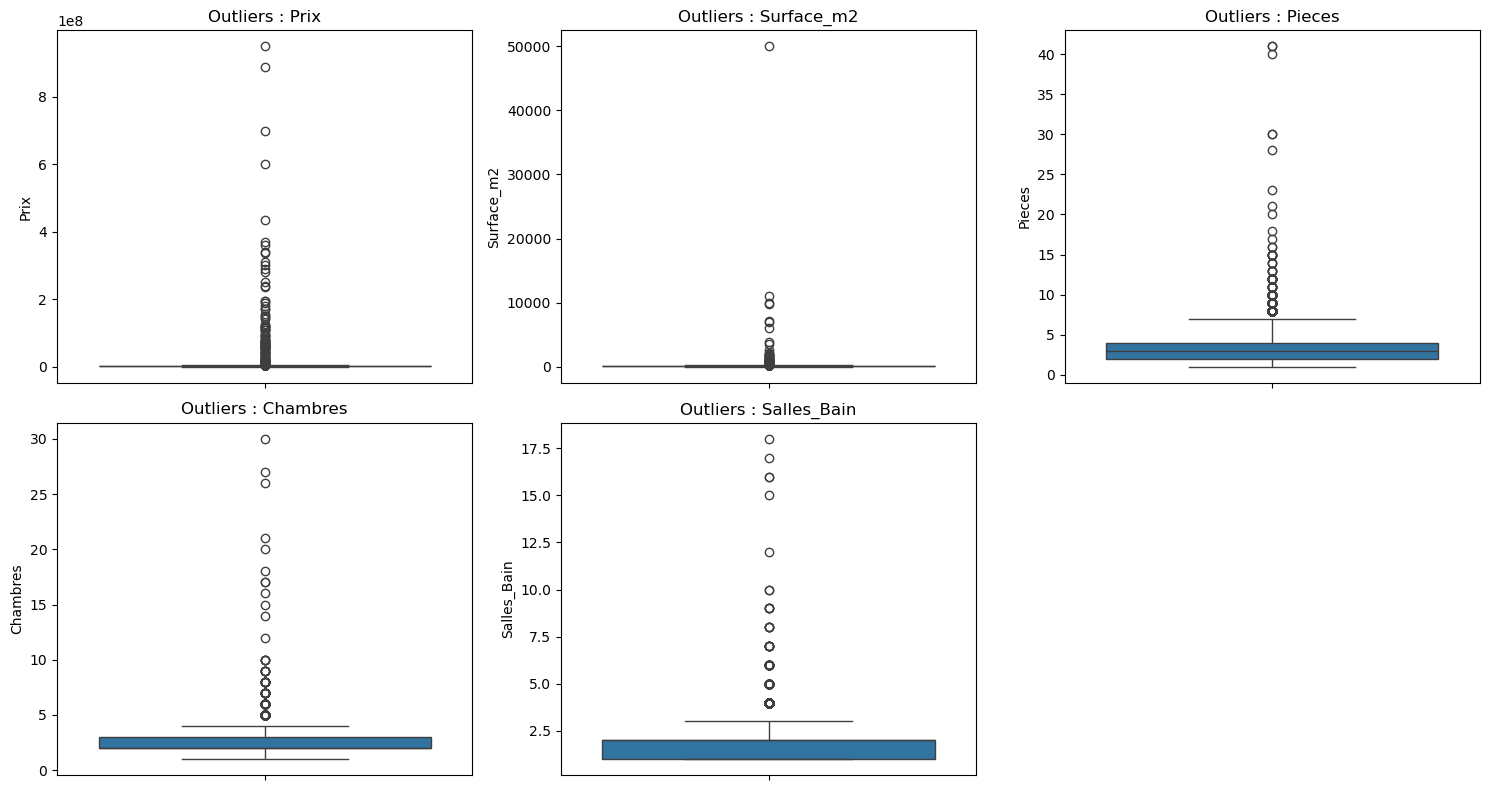

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

# Liste des colonnes numériques
numeric_cols = ['Prix', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain']

# Affichage des boxplots
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col].dropna()) # On ignore les NaN pour l'affichage
    plt.title(f'Outliers : {col}')

plt.tight_layout()
plt.show()

Étape 1 : Nettoyage par IQR (Élimination des erreurs de saisie)
IQR pour les colonnes 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain'

In [135]:
# Liste des colonnes techniques à nettoyer par IQR
cols_to_clean = ['Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain']

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # On garde les lignes dans l'intervalle
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Application du filtre IQR
df_iqr = remove_outliers_iqr(df, cols_to_clean)
print(f"Lignes après IQR : {len(df_iqr)}")

Lignes après IQR : 11847


Étape 2 : Isolation Forest (Détection des profils atypiques)

In [136]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

# Sélection des colonnes numériques pour le calcul de l'anomalie
features_iso = ['Prix', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain']

# 1. Imputation temporaire pour Isolation Forest
imputer_temp = SimpleImputer(strategy='median')
data_temp = imputer_temp.fit_transform(df_iqr[features_iso])

# 2. Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(data_temp)

# 3. Filtrage : on ne garde que les lignes où outliers == 1
df_iso = df_iqr[outliers == 1].copy()
print(f"Lignes après Isolation Forest : {len(df_iso)}")

Lignes après Isolation Forest : 11254


### imputation des missing valeurs par KNNimputer

In [137]:
from sklearn.impute import KNNImputer

# 1. Préparation des colonnes pour l'imputation
# On utilise toutes les colonnes numériques (inclus les One-Hot)
features_knn = ['Prix', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 
                'type_appartement', 'type_studio', 'type_maison', 'type_villa', 
                'type_duplex', 'Is_Haut_Standing', 'En_Construction']

# 2. Initialisation du KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# 3. Application de l'imputation sur df_iso
# Note: On crée une copie pour ne pas altérer le dataframe précédent
df = df_iso.copy()
df[features_knn] = imputer.fit_transform(df_iso[features_knn])

print("Imputation terminée. Ton dataframe 'df' est prêt pour le Split !")

Imputation terminée. Ton dataframe 'df' est prêt pour le Split !


In [138]:
df.columns

Index(['Titre', 'Prix', 'Localisation', 'type_appartement', 'type_studio',
       'type_maison', 'type_villa', 'type_duplex', 'Quartier', 'Ville',
       'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Is_Haut_Standing',
       'En_Construction'],
      dtype='object')

In [139]:
# Imputer Quartier b l mode (l a9rab fréquent) dial nefs la Ville
mode_par_ville = df.groupby('Ville')['Quartier'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'Inconnu'
)

def imputer_quartier(row):
    if pd.isna(row['Quartier']):
        return mode_par_ville.get(row['Ville'], 'Inconnu')
    return row['Quartier']

df['Quartier'] = df.apply(imputer_quartier, axis=1)
df['Quartier'] = df['Quartier'].fillna('Inconnu')  # sécurité ila villa nadra

df.isnull().sum()

Titre               0
Prix                0
Localisation        0
type_appartement    0
type_studio         0
type_maison         0
type_villa          0
type_duplex         0
Quartier            0
Ville               0
Surface_m2          0
Pieces              0
Chambres            0
Salles_Bain         0
Is_Haut_Standing    0
En_Construction     0
dtype: int64

In [140]:
df.head(10)

,Titre,Prix,Localisation,type_appartement,type_studio,type_maison,type_villa,type_duplex,Quartier,Ville,Surface_m2,Pieces,Chambres,Salles_Bain,Is_Haut_Standing,En_Construction
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730000.0,"Guéliz, Marrakech",0.0,1.0,0.0,0.0,0.0,Guéliz,Marrakech,42.0,2.0,1.0,1.0,0.0,0.0
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980000.0,"Route de Ouarzazate, Marrakech",1.0,0.0,0.0,0.0,0.0,Route de Ouarzazate,Marrakech,116.0,3.0,2.0,2.0,0.0,0.0
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1242000.0,"Les Hôpitaux, Casablanca",1.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,47.0,1.0,1.0,1.0,0.0,0.0
5,Appartement à l'achat à Californie. 2 chambres...,1712500.0,"Californie, Casablanca",1.0,0.0,0.0,0.0,0.0,Californie,Casablanca,100.0,3.0,2.0,2.0,0.0,0.0
6,Vente d'un bel appartement à Belvédère. 2 bell...,950000.0,"Belvédère, Casablanca",1.0,0.0,0.0,0.0,0.0,Belvédère,Casablanca,82.0,3.0,2.0,1.0,0.0,0.0
7,Appartement neuf résidence azzahra 2 said hajji,370000.0,"Abouab Sala, Salé",1.0,0.0,0.0,0.0,0.0,Abouab Sala,Salé,53.0,3.0,2.0,1.0,0.0,0.0
9,Superbe appartement à casablanca: 181 m² 2 pp,2800000.0,"Maârif Extension, Casablanca",1.0,0.0,0.0,0.0,0.0,Maârif Extension,Casablanca,181.0,3.0,3.0,2.0,0.0,0.0
10,Studios & Appartements à vendre avec piscine,1300000.0,"Agdal, Marrakech",1.0,1.0,0.0,0.0,0.0,Agdal,Marrakech,58.0,1.0,1.0,1.0,0.0,0.0
11,Joli studio meublé à noria golf,1500000.0,"Route de Tahanaout, Marrakech",0.0,1.0,0.0,0.0,0.0,Route de Tahanaout,Marrakech,40.0,2.0,1.0,1.0,0.0,0.0
13,Appartement à vendre à Les Hôpitaux. 1 belle c...,1345000.0,"Les Hôpitaux, Casablanca",1.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,53.0,1.0,1.0,1.0,0.0,0.0


## etapes de verification 

In [141]:
df.isnull().sum()

Titre               0
Prix                0
Localisation        0
type_appartement    0
type_studio         0
type_maison         0
type_villa          0
type_duplex         0
Quartier            0
Ville               0
Surface_m2          0
Pieces              0
Chambres            0
Salles_Bain         0
Is_Haut_Standing    0
En_Construction     0
dtype: int64

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11254 entries, 0 to 16857
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Titre             11254 non-null  object 
 1   Prix              11254 non-null  float64
 2   Localisation      11254 non-null  object 
 3   type_appartement  11254 non-null  float64
 4   type_studio       11254 non-null  float64
 5   type_maison       11254 non-null  float64
 6   type_villa        11254 non-null  float64
 7   type_duplex       11254 non-null  float64
 8   Quartier          11254 non-null  object 
 9   Ville             11254 non-null  object 
 10  Surface_m2        11254 non-null  float64
 11  Pieces            11254 non-null  float64
 12  Chambres          11254 non-null  float64
 13  Salles_Bain       11254 non-null  float64
 14  Is_Haut_Standing  11254 non-null  float64
 15  En_Construction   11254 non-null  float64
dtypes: float64(12), object(4)
memory usage: 1.5+ 

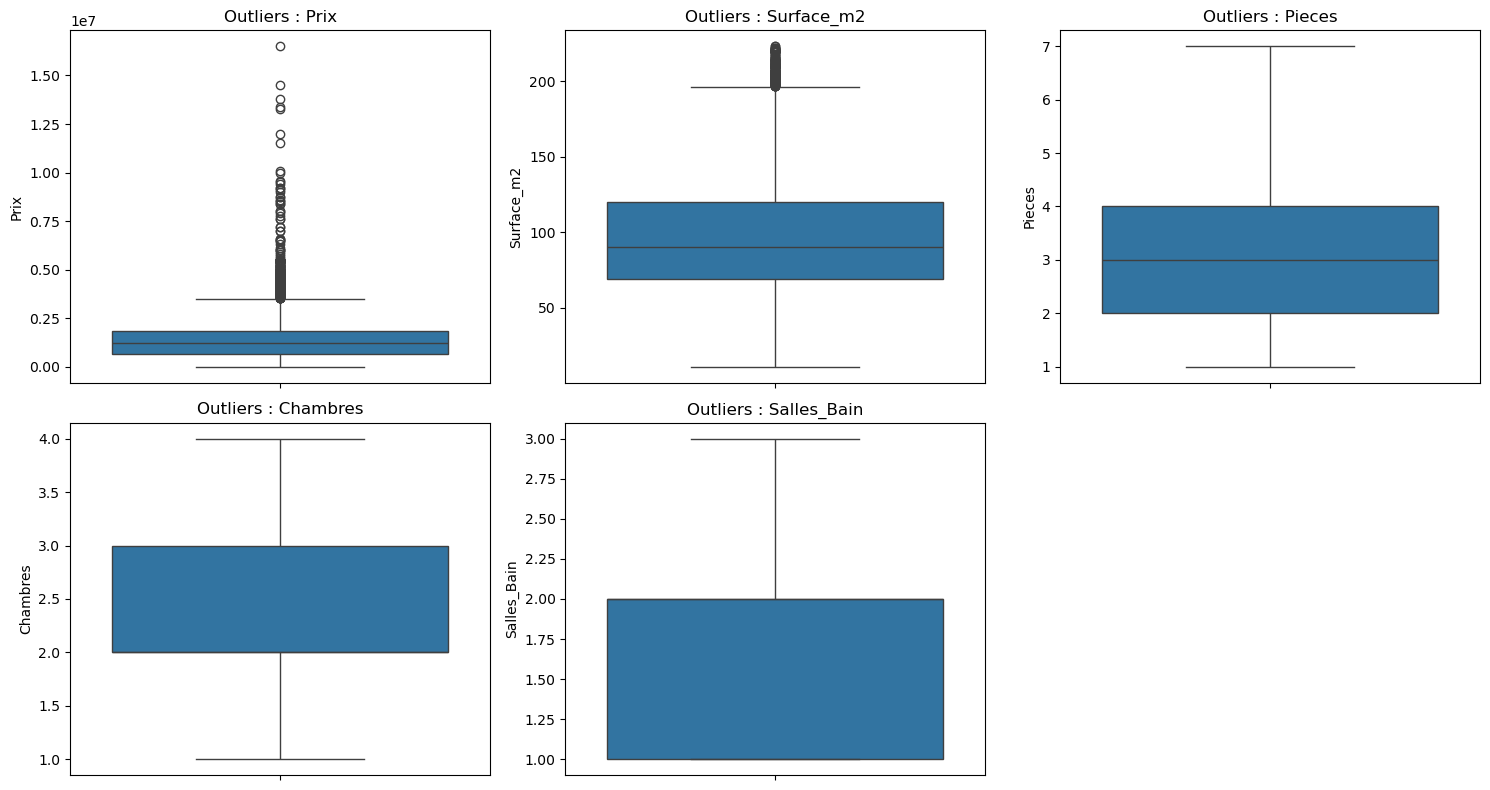

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

# Liste des colonnes numériques
numeric_cols = ['Prix', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain']

# Affichage des boxplots
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col].dropna()) # On ignore les NaN pour l'affichage
    plt.title(f'Outliers : {col}')

plt.tight_layout()
plt.show()

# 4- L'analyse exploratoire des données (EDA)

### 1. Quel est le prix moyen des biens immobiliers par grande ville marocaine ?

Ville
Ait Haddou Youssef         3.700000e+06
Bir Tam Tam                3.500000e+06
Taghazout                  2.999118e+06
Rabat                      2.538725e+06
El Menzeh                  2.509333e+06
Sidi Bouknadel             2.258571e+06
El Majjatia Ouled Taleb    2.090000e+06
Taroudant                  2.052000e+06
Harhoura                   2.028750e+06
Sidi Yahya Zaer            1.966667e+06
Name: Prix, dtype: float64


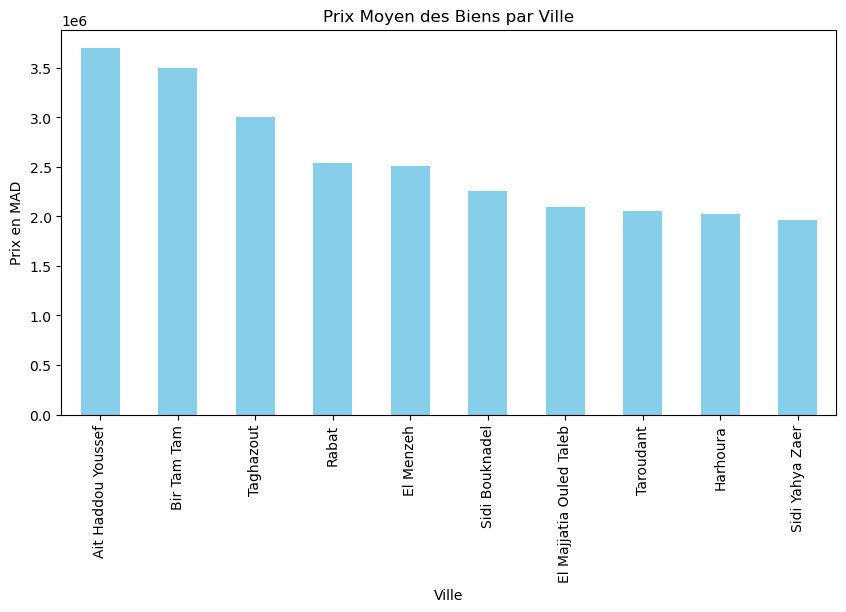

In [144]:
# Moyenne des prix par ville
prix_par_ville = df.groupby('Ville')['Prix'].mean().sort_values(ascending=False).head(10)
print(prix_par_ville)

# Visualisation simple en barplot
prix_par_ville.plot(kind='bar', color='skyblue', figsize=(10, 5))
plt.title('Prix Moyen des Biens par Ville')
plt.ylabel('Prix en MAD')
plt.show()

### 2. Quelle est la relation entre la surface du bien (Surface_m2) et son prix (Prix) ?

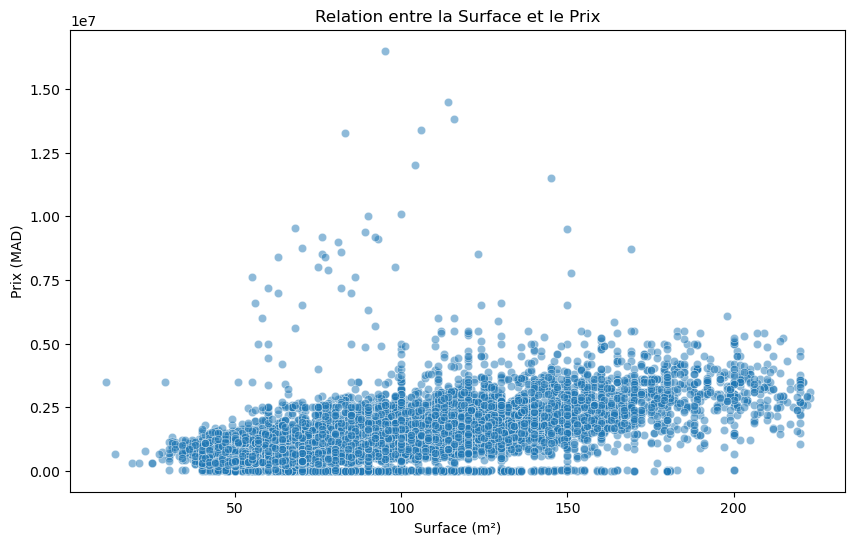

In [145]:
# Scatter plot simple entre la surface et le prix
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Surface_m2', y='Prix', alpha=0.5)
plt.title('Relation entre la Surface et le Prix')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (MAD)')
plt.show()

### 3. Quelle est la répartition des types de biens immobiliers sur le portail ?

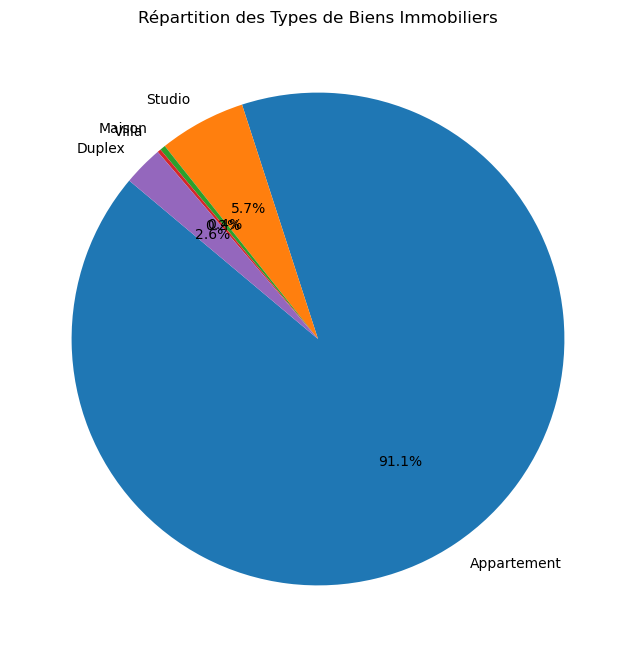

In [146]:
# Somme des colonnes binaires d'encoding
types_biens = {
    'Appartement': df['type_appartement'].sum(),
    'Studio': df['type_studio'].sum(),
    'Maison': df['type_maison'].sum(),
    'Villa': df['type_villa'].sum(),
    'Duplex': df['type_duplex'].sum()
}

# Conversion en Series pour affichage
s_types = pd.Series(types_biens)
s_types.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), startangle=140)
plt.title('Répartition des Types de Biens Immobiliers')
plt.ylabel('')
plt.show()

### 4. Quels sont les quartiers les plus chers en moyenne ?

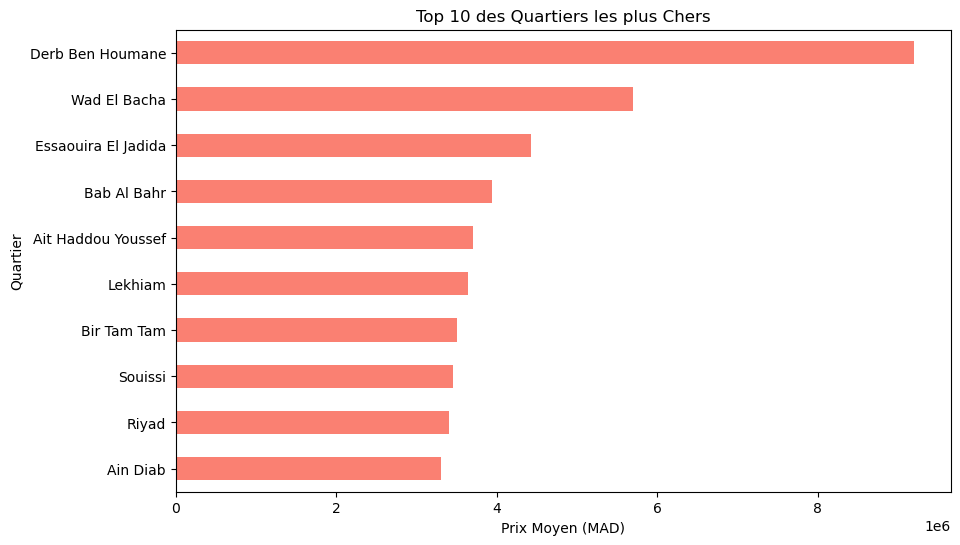

In [147]:
# Top 10 des quartiers les plus chers
top_quartiers = df.groupby('Quartier')['Prix'].mean().sort_values(ascending=False).head(10)

top_quartiers.plot(kind='barh', color='salmon', figsize=(10, 6))
plt.title('Top 10 des Quartiers les plus Chers')
plt.xlabel('Prix Moyen (MAD)')
plt.gca().invert_yaxis() # Bash yban l-li ghalya l-foq
plt.show()

### 5. Comment se répartit le nombre de chambres (Chambres) dans les biens proposés ?

C:\Users\Pc\AppData\Local\Temp\ipykernel_31320\2151193527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Chambres', palette='viridis')


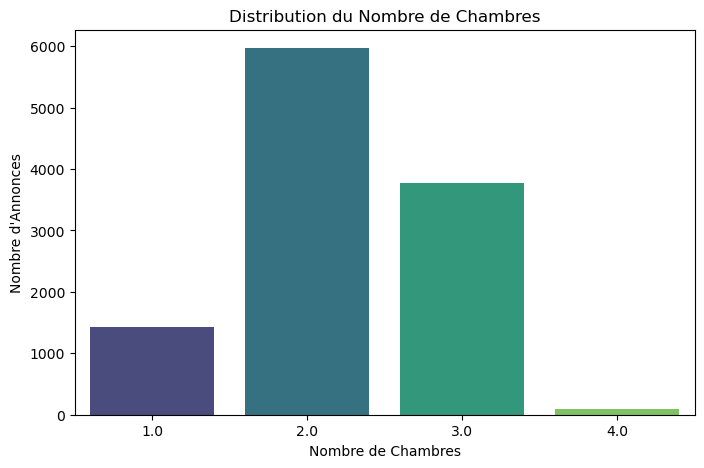

In [148]:
# Distribution du nombre de chambres
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Chambres', palette='viridis')
plt.title('Distribution du Nombre de Chambres')
plt.xlabel('Nombre de Chambres')
plt.ylabel("Nombre d'Annonces")
plt.show()

### 6. Quelle est la proportion des différents types de biens immobiliers

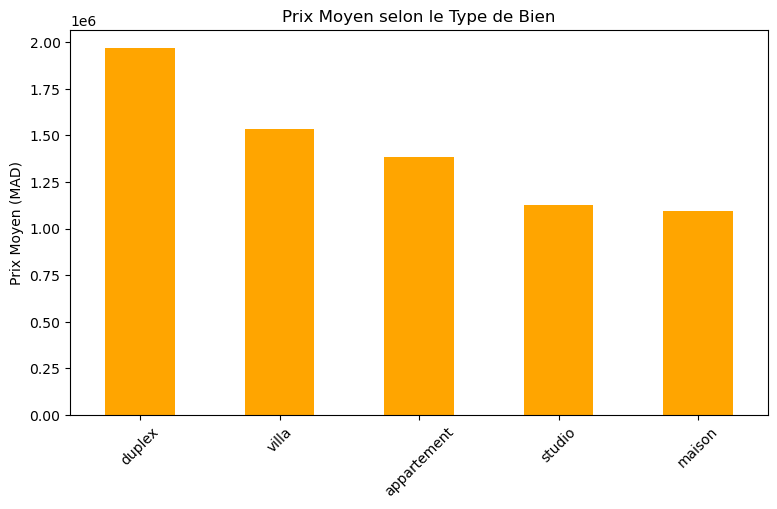

In [149]:
# Calculer le prix moyen pour chaque type de bien binaire
types_cols = ['type_appartement', 'type_studio', 'type_maison', 'type_villa', 'type_duplex']
prix_par_type = {col.replace('type_', ''): df[df[col] == 1]['Prix'].mean() for col in types_cols}

s_prix_types = pd.Series(prix_par_type).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
s_prix_types.plot(kind='bar', color='orange')
plt.title("Prix Moyen selon le Type de Bien")
plt.ylabel("Prix Moyen (MAD)")
plt.xticks(rotation=45)
plt.show()

### 7. Comment se répartit le nombre de pièces (Pieces) dans les annonces immobilières ?

C:\Users\Pc\AppData\Local\Temp\ipykernel_31320\2154358496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pieces', palette='magma')


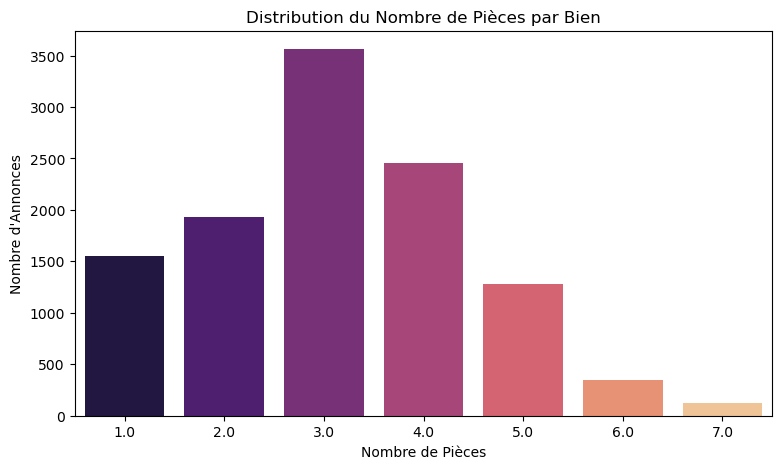

In [150]:
# Distribution du nombre de pièces
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Pieces', palette='magma')
plt.title("Distribution du Nombre de Pièces par Bien")
plt.xlabel("Nombre de Pièces")
plt.ylabel("Nombre d'Annonces")
plt.show()

### 8. Quel est l'impact de la présence d'un "Studio" ou d'un "Duplex" sur le prix global par rapport à un appartement standard ?

C:\Users\Pc\AppData\Local\Temp\ipykernel_31320\2194687443.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type_Principal', y='Prix', palette='Set3')


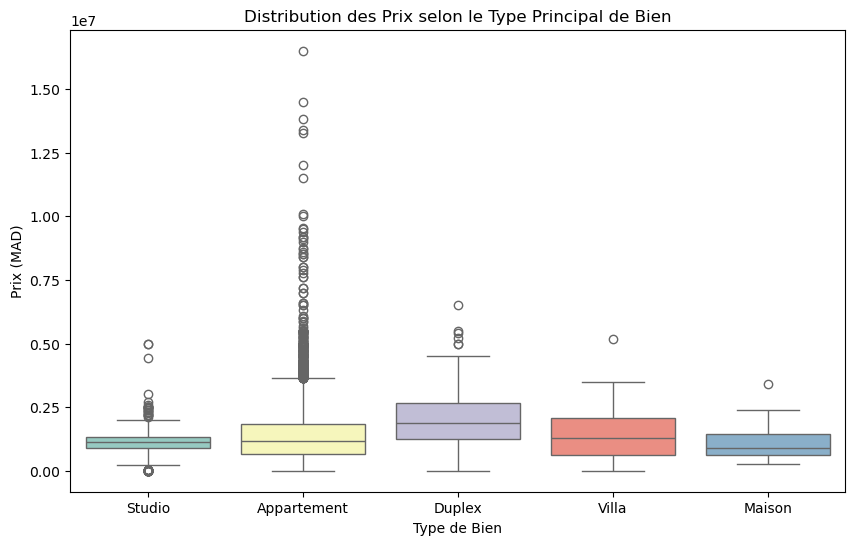

In [151]:
# Créer une colonne catégorielle principale du type de bien pour le boxplot
def get_main_type(row):
    if row['type_studio'] == 1: return 'Studio'
    elif row['type_duplex'] == 1: return 'Duplex'
    elif row['type_villa'] == 1: return 'Villa'
    elif row['type_maison'] == 1: return 'Maison'
    else: return 'Appartement'

df['Type_Principal'] = df.apply(get_main_type, axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Type_Principal', y='Prix', palette='Set3')
plt.title("Distribution des Prix selon le Type Principal de Bien")
plt.xlabel("Type de Bien")
plt.ylabel("Prix (MAD)")
plt.show()

### 9. Quelle est la concentration des annonces immobilières par quartier (Top 10 des quartiers les plus actifs) ?

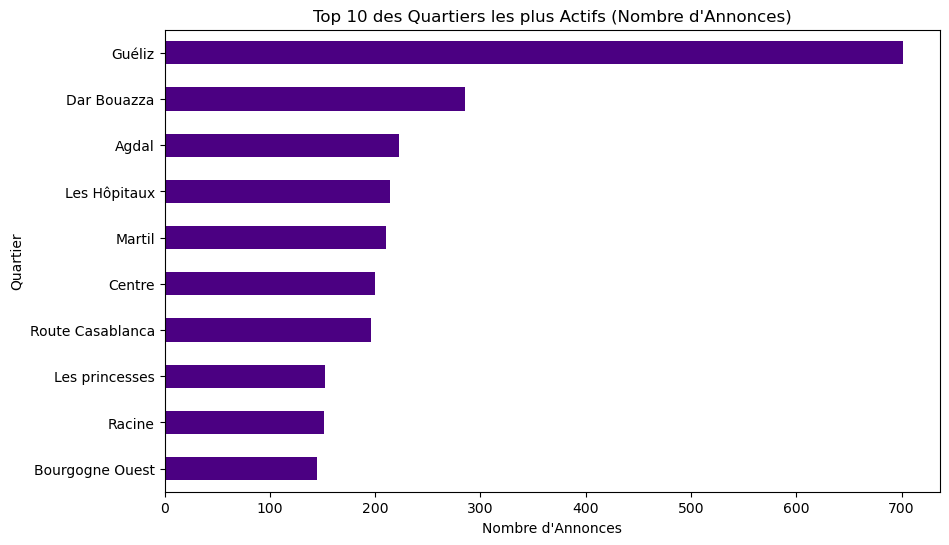

In [152]:
# Compter le nombre d'annonces par quartier
top_quartiers_activite = df['Quartier'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_quartiers_activite.plot(kind='barh', color='indigo')
plt.title("Top 10 des Quartiers les plus Actifs (Nombre d'Annonces)")
plt.xlabel("Nombre d'Annonces")
plt.ylabel("Quartier")
plt.gca().invert_yaxis()
plt.show()

### 10. Quel est l'impact du nombre de pièces (Pieces) sur le prix moyen global d'un bien ?

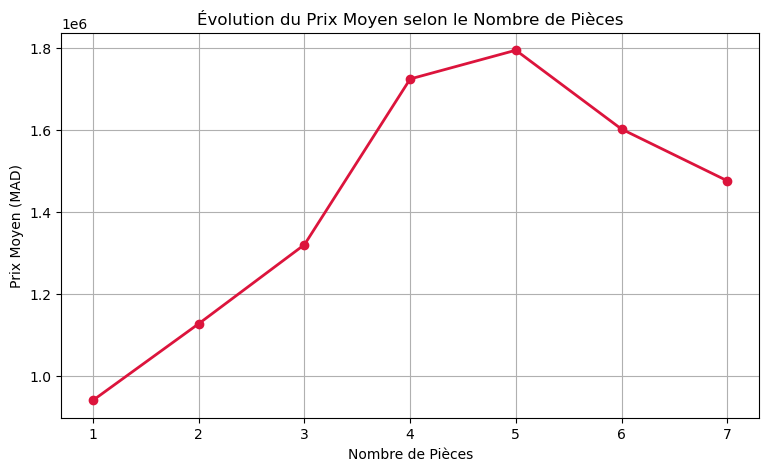

In [153]:
# Calculer le prix moyen par nombre de pièces
prix_par_piece = df.groupby('Pieces')['Prix'].mean()

plt.figure(figsize=(9, 5))
prix_par_piece.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title("Évolution du Prix Moyen selon le Nombre de Pièces")
plt.xlabel("Nombre de Pièces")
plt.ylabel("Prix Moyen (MAD)")
plt.grid(True)
plt.show()

### 11. Quelle est la part des biens immobiliers possédant un nombre élevé de chambres (par exemple, 4 chambres et plus) par rapport aux petits biens ?

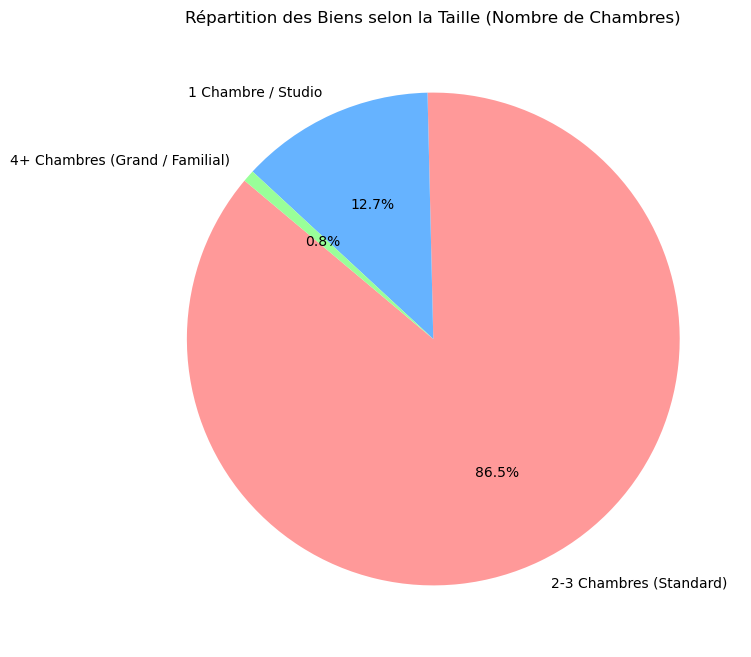

In [154]:
# Créer des catégories de taille de biens selon les chambres
def categoriser_chambres(nb):
    if nb <= 1:
        return '1 Chambre / Studio'
    elif nb == 2 or nb == 3:
        return '2-3 Chambres (Standard)'
    else:
        return '4+ Chambres (Grand / Familial)'

df['Categorie_Chambres'] = df['Chambres'].apply(categoriser_chambres)
repartition_taille = df['Categorie_Chambres'].value_counts()

plt.figure(figsize=(8, 8))
repartition_taille.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title("Répartition des Biens selon la Taille (Nombre de Chambres)")
plt.ylabel('')
plt.show()

# 5- partie preprocssing

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11254 entries, 0 to 16857
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Titre               11254 non-null  object 
 1   Prix                11254 non-null  float64
 2   Localisation        11254 non-null  object 
 3   type_appartement    11254 non-null  float64
 4   type_studio         11254 non-null  float64
 5   type_maison         11254 non-null  float64
 6   type_villa          11254 non-null  float64
 7   type_duplex         11254 non-null  float64
 8   Quartier            11254 non-null  object 
 9   Ville               11254 non-null  object 
 10  Surface_m2          11254 non-null  float64
 11  Pieces              11254 non-null  float64
 12  Chambres            11254 non-null  float64
 13  Salles_Bain         11254 non-null  float64
 14  Is_Haut_Standing    11254 non-null  float64
 15  En_Construction     11254 non-null  float64
 16  Type_Prin

In [156]:
df

,Titre,Prix,Localisation,type_appartement,type_studio,type_maison,type_villa,type_duplex,Quartier,Ville,Surface_m2,Pieces,Chambres,Salles_Bain,Is_Haut_Standing,En_Construction,Type_Principal,Categorie_Chambres
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730000.0,"Guéliz, Marrakech",0.0,1.0,0.0,0.0,0.0,Guéliz,Marrakech,42.0,2.0,1.0,1.0,0.0,0.0,Studio,1 Chambre / Studio
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980000.0,"Route de Ouarzazate, Marrakech",1.0,0.0,0.0,0.0,0.0,Route de Ouarzazate,Marrakech,116.0,3.0,2.0,2.0,0.0,0.0,Appartement,2-3 Chambres (Standard)
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1242000.0,"Les Hôpitaux, Casablanca",1.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,47.0,1.0,1.0,1.0,0.0,0.0,Appartement,1 Chambre / Studio
5,Appartement à l'achat à Californie. 2 chambres...,1712500.0,"Californie, Casablanca",1.0,0.0,0.0,0.0,0.0,Californie,Casablanca,100.0,3.0,2.0,2.0,0.0,0.0,Appartement,2-3 Chambres (Standard)
6,Vente d'un bel appartement à Belvédère. 2 bell...,950000.0,"Belvédère, Casablanca",1.0,0.0,0.0,0.0,0.0,Belvédère,Casablanca,82.0,3.0,2.0,1.0,0.0,0.0,Appartement,2-3 Chambres (Standard)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16850,Terrasse gauthier belle affaire,900000.0,Casablanca,0.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,62.0,2.0,1.0,1.0,0.0,0.0,Appartement,1 Chambre / Studio
16852,Meuble en plein coeur de gauthier,850000.0,Casablanca,0.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,48.0,2.0,1.0,1.0,0.0,0.0,Appartement,1 Chambre / Studio
16855,Proche zara bel appartement etage eleve,2300000.0,Casablanca,1.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,140.0,5.0,3.0,2.0,0.0,0.0,Appartement,2-3 Chambres (Standard)
16856,Socrate mawlid,1300000.0,Casablanca,0.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,108.0,3.0,2.0,2.0,0.0,0.0,Appartement,2-3 Chambres (Standard)


## 5.1 Suppression des colonnes non pertinentes pour le modèle

- `Titre` : texte libre, pas exploitable tel quel pour le ML.
- `Localisation` : déjà splitée en `Ville` et `Quartier`, devenue redondante.
- `Type_Principal` : version texte redondante avec les colonnes one-hot `type_appartement`, `type_studio`, etc.
- `Categorie_Chambres` : dérivée directement de `Chambres` (déjà numérique), on évite la redondance / fuite d'info.

In [157]:
colonnes_a_supprimer = ['Titre', 'Localisation', 'Type_Principal', 'Categorie_Chambres']
df_model = df.drop(columns=colonnes_a_supprimer)
df_model.head()

,Prix,type_appartement,type_studio,type_maison,type_villa,type_duplex,Quartier,Ville,Surface_m2,Pieces,Chambres,Salles_Bain,Is_Haut_Standing,En_Construction
0,730000.0,0.0,1.0,0.0,0.0,0.0,Guéliz,Marrakech,42.0,2.0,1.0,1.0,0.0,0.0
1,980000.0,1.0,0.0,0.0,0.0,0.0,Route de Ouarzazate,Marrakech,116.0,3.0,2.0,2.0,0.0,0.0
4,1242000.0,1.0,0.0,0.0,0.0,0.0,Les Hôpitaux,Casablanca,47.0,1.0,1.0,1.0,0.0,0.0
5,1712500.0,1.0,0.0,0.0,0.0,0.0,Californie,Casablanca,100.0,3.0,2.0,2.0,0.0,0.0
6,950000.0,1.0,0.0,0.0,0.0,0.0,Belvédère,Casablanca,82.0,3.0,2.0,1.0,0.0,0.0


## 5.3 Encodage des variables categorielles

In [158]:
# Encodage par fréquence pour Quartier (haute cardinalité)
freq_quartier = df_model['Quartier'].value_counts(normalize=True)
df_model['Quartier_freq'] = df_model['Quartier'].map(freq_quartier)
df_model.drop(columns=['Quartier'], inplace=True)

# One-Hot Encoding pour Ville (cardinalité raisonnable)
df_model = pd.get_dummies(df_model, columns=['Ville'], prefix='ville', drop_first=True)

df_model.head()

,Prix,type_appartement,type_studio,type_maison,type_villa,type_duplex,Surface_m2,Pieces,Chambres,Salles_Bain,...,ville_Taza,ville_Temara,ville_Tifelt,ville_Tit Mellil,ville_Tiznit,ville_Tnine Aglou,ville_Tétouan,ville_Zaouiat Sidi Kacem,ville_Zenata,ville_Zoumi
0,730000.0,0.0,1.0,0.0,0.0,0.0,42.0,2.0,1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,980000.0,1.0,0.0,0.0,0.0,0.0,116.0,3.0,2.0,2.0,...,False,False,False,False,False,False,False,False,False,False
4,1242000.0,1.0,0.0,0.0,0.0,0.0,47.0,1.0,1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
5,1712500.0,1.0,0.0,0.0,0.0,0.0,100.0,3.0,2.0,2.0,...,False,False,False,False,False,False,False,False,False,False
6,950000.0,1.0,0.0,0.0,0.0,0.0,82.0,3.0,2.0,1.0,...,False,False,False,False,False,False,False,False,False,False


## 5.4 Séparation Features (X) / Target (y)

In [159]:
X = df_model.drop(columns=['Prix'])
y = df_model['Prix']

print("X :", X.shape)
print("y :", y.shape)

X : (11254, 157)
y : (11254,)


## 5.5 Split Train / Test

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (9003, 157) (9003,)
Test  : (2251, 157) (2251,)


## 5.6 Mise à l'échelle des variables numériques : Standardisation vs Normalisation

### 5.6.1 Standardisation (`StandardScaler`)

In [161]:
cols_numeriques = ['Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Quartier_freq']

standard_scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

# fit_transform SEULEMENT sur le train
X_train_std[cols_numeriques] = standard_scaler.fit_transform(X_train[cols_numeriques])
# transform (sans fit) sur le test, avec les paramètres appris sur le train
X_test_std[cols_numeriques] = standard_scaler.transform(X_test[cols_numeriques])

X_train_std[cols_numeriques].describe()

,Surface_m2,Pieces,Chambres,Salles_Bain,Quartier_freq
count,9.003000e+03,9.003000e+03,9.003000e+03,9.003000e+03,9.003000e+03
mean,2.051995e-17,-1.006267e-16,-1.104920e-17,-1.558727e-16,5.287833e-17
std,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00
min,-2.295127e+00,-1.570715e+00,-1.833912e+00,-1.084018e+00,-6.991765e-01
25%,-7.393620e-01,-8.342352e-01,-3.344378e-01,-1.084018e+00,-5.848344e-01
50%,-1.760677e-01,-9.775554e-02,-3.344378e-01,6.003821e-01,-2.959700e-01
75%,6.286386e-01,6.387241e-01,1.165036e+00,6.003821e-01,1.373266e-01
max,3.391463e+00,2.848163e+00,2.664510e+00,2.284782e+00,3.513429e+00


Après standardisation, chaque colonne numérique doit avoir une moyenne ≈ 0 et un écart-type ≈ 1 (visible dans le `describe()` ci-dessus).

### 5.6.2 Normalisation (`MinMaxScaler`)

In [162]:
minmax_scaler = MinMaxScaler()

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[cols_numeriques] = minmax_scaler.fit_transform(X_train[cols_numeriques])
X_test_norm[cols_numeriques] = minmax_scaler.transform(X_test[cols_numeriques])

X_train_norm[cols_numeriques].describe()

,Surface_m2,Pieces,Chambres,Salles_Bain,Quartier_freq
count,9003.000000,9003.000000,9003.000000,9003.000000,9003.000000
mean,0.403603,0.355456,0.407679,0.321782,0.165972
std,0.175862,0.226314,0.222313,0.296858,0.237396
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.273585,0.166667,0.333333,0.000000,0.027143
50%,0.372642,0.333333,0.333333,0.500000,0.095714
75%,0.514151,0.500000,0.666667,0.500000,0.198571
max,1.000000,1.000000,1.000000,1.000000,1.000000


Après normalisation, chaque colonne numérique doit avoir un minimum = 0 et un maximum = 1. Remarque : sur `X_test_norm`, il est possible d'avoir des valeurs légèrement < 0 ou > 1 si le test contient des valeurs plus extrêmes que le train — c'est normal, pas une erreur.

### 5.6.3 Comparaison visuelle

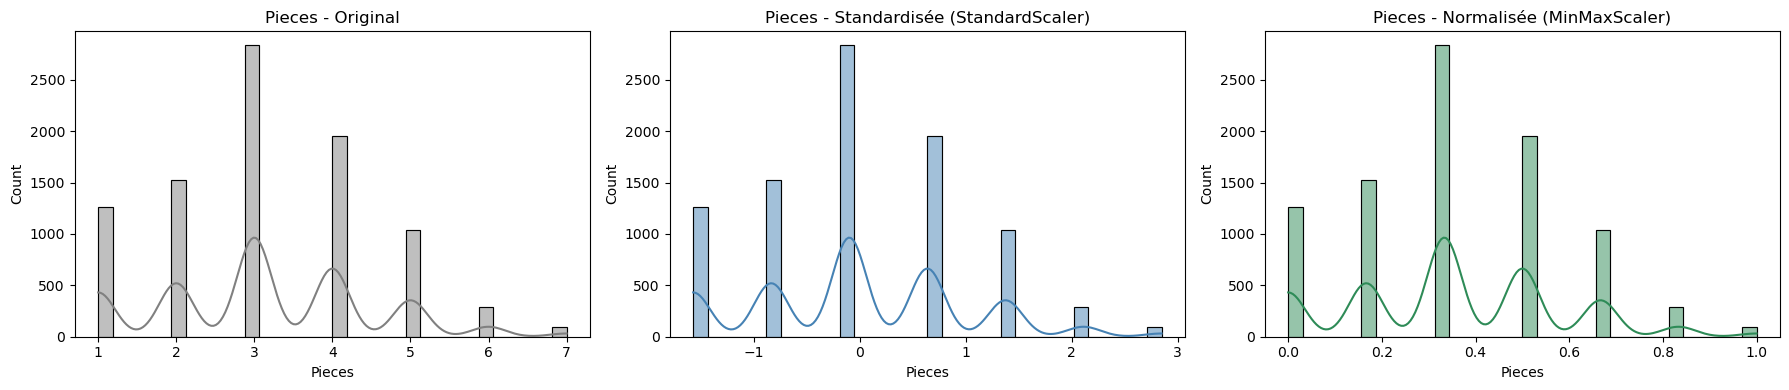

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(X_train['Pieces'], kde=True, ax=axes[0], color='gray')
axes[0].set_title('Pieces - Original')

sns.histplot(X_train_std['Pieces'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Pieces - Standardisée (StandardScaler)')

sns.histplot(X_train_norm['Pieces'], kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('Pieces - Normalisée (MinMaxScaler)')

plt.tight_layout()
plt.show()

On remarque que la **forme** de la distribution ne change pas (ni standardisation ni normalisation ne corrigent l'asymétrie/skew) — seule l'**échelle** change. On garde `X_train_std` / `X_test_std` pour la suite (partie Machine Learning), car mieux adapté à la régression.

# 6- partie MACHINE LEARNING 

In [164]:
df.columns

Index(['Titre', 'Prix', 'Localisation', 'type_appartement', 'type_studio',
       'type_maison', 'type_villa', 'type_duplex', 'Quartier', 'Ville',
       'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Is_Haut_Standing',
       'En_Construction', 'Type_Principal', 'Categorie_Chambres'],
      dtype='object')

In [165]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Sélection des features
features = [
    'type_appartement', 'type_studio', 'type_maison', 'type_villa', 'type_duplex', 
    'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Is_Haut_Standing', 'En_Construction'
]

X = df_model[features]
y = df_model['Prix']

# 2. Split l-data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling ضروري 3la 9bel KNN w SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Dictionnaire des modèles m-zidin lihom les hyperparamètres
models = {
    "Ridge Regression (Linear avec régularisation)": Ridge(alpha=10.0),
    
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=10,         # Kat7did l'3om9 l-a9sa dyal l-chajara bach t-mn3 l'overfitting
        min_samples_split=10, # A9sa 3adad dyal l-samples bach ndiro split
        random_state=42
    ),
    
    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=7,        # 3adad l-jiwran (k-nsdéw biha l'bruit)
        weights='distance',   # L-jiwran l-9rab 9ribin bzaf kay-kon 3ndhom wazn kbir f l-9rar
        metric='manhattan'    # Tariqa dyal 7isab l-masafa
    ),
    
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=150,     # 3adad l-chajrat (150 chajara)
        max_depth=15,         # L'3om9 l-a9sa l kol chajara
        min_samples_split=5,
        random_state=42,
        n_jobs=-1             # Kat-khdem b Processor kamel bach t-sri3 l-apprentissage
    ),
    
    "SVR (Support Vector Regressor)": SVR(
        kernel='rbf',         # RBF kernel l-ahsan l non-linear data
        C=1000.0,             # Regularization parameter (kbir bach y-tiri m3a les valeurs dyal l'prix b dabet)
        epsilon=0.1           # Margin of tolerance
    )
}

# 5. Boucle bach n-trentiw w n-testiw kol model
for name, model in models.items():
    try:
        # Wach n-khdmo b l'data m-scaleriya wela 3adiya? (KNN w SVR kay-bghiw scaled)
        if name in ["KNN Regressor", "SVR (Support Vector Regressor)"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        # Evaluation
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        print(f"==============================")
        print(f"📌 Model: {name}")
        print(f"==============================")
        print(f"R² Score: {r2:.4f}")
        print(f"RMSE: {rmse:,.2f} DH\n")
        
    except Exception as e:
        print(f"⚠️ 3ndk mochkil f {name}: {e}\n")

📌 Model: Ridge Regression (Linear avec régularisation)
R² Score: 0.3456
RMSE: 836,945.95 DH

📌 Model: Decision Tree Regressor
R² Score: 0.2765
RMSE: 880,036.13 DH

📌 Model: KNN Regressor
R² Score: 0.2206
RMSE: 913,400.39 DH

📌 Model: Random Forest Regressor
R² Score: 0.2986
RMSE: 866,490.63 DH

📌 Model: SVR (Support Vector Regressor)
R² Score: 0.1884
RMSE: 932,056.23 DH

